# Hamiltonian Monte Carlo

This notebook reproduces plots and code from my [blog post](https://tcbegley.com/blog/mcmc-part-2) on Hamiltonian Monte Carlo. If you're interested in the theory behind the code below, check out the post.

Note that all implementations here are designed for simplicity and clarity rather than performance.

To make the animations, you will need to install `ffmpeg`. See [here](https://ffmpeg.org/download.html) for installation options, or use your favourite package manager.

You will also need `matplotlib` and `numpy` installed. You can run the cell below to install if you don't already have them.

In [1]:
import sys

!{sys.executable} -m pip install -U matplotlib numpy

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Video
from matplotlib.animation import FFMpegWriter

This is the basic Metropolis algorithm, it's very simple. Accumulating samples by appending to a list is sub-optimal, but my goal here is clarity / simplicity rather than performance.

- `target` is the target probability density, it should accept a sample as its only argument and return the probability density of that sample.
- `initial` is a function that returns the starting point in parameter space. It is a callable which takes no arguments.
- `proposal` is the proposal distribution, it takes the current sample as its argument and returns a proposal for the next sample.

In [3]:
def metropolis(target, initial, proposal, iterations=100_000):
    samples = [initial()]

    for _ in range(iterations):
        current = samples[-1]
        proposed = proposal(current)
        if np.random.random() < target(proposed) / target(current):
            samples.append(proposed)
        else:
            samples.append(current)

    return samples

A standard, simple choice of proposal is a normally distributed jump from the current location. This gives rise to Random Walk Metropolis.

In [4]:
class NormalProposal:
    def __init__(self, scale):
        self.scale = scale

    def __call__(self, sample):
        jump = np.random.normal(scale=self.scale, size=sample.shape)
        return sample + jump

We'll start by sampling from a radially symmetric donut shaped distribution. The density decays exponentially with the distance from a circle of fixed radius. We can implement the target distribution as a callable object by writing a custom class and implementing the `__call__` magic method. In this case `__call__` returns an unnormalised form of the donut shaped density.

In [5]:
class DonutPDF:
    def __init__(self, radius=3, sigma2=0.05):
        self.radius = radius
        self.sigma2 = sigma2

    def __call__(self, x):
        r = np.linalg.norm(x)
        return np.exp(-((r - self.radius) ** 2) / self.sigma2)

We can adjust the scale of the normal distribution that determines the jumps, but both small and large scales have their problems which the below plot shows.

In [6]:
target = DonutPDF()
samples05 = np.array(metropolis(target, lambda: np.array([3, 0]), NormalProposal(0.05)))
samples1 = np.array(metropolis(target, lambda: np.array([3, 0]), NormalProposal(1)))

In [7]:
f, ax = plt.subplots(figsize=(16, 8), ncols=2)
ax[0].tick_params(axis="both", which="major", labelsize=14)
ax[1].tick_params(axis="both", which="major", labelsize=14)

points = np.linspace(-4, 4, 301)
x = np.tile(points, len(points))
y = np.repeat(points, len(points))

z = np.exp(np.apply_along_axis(target, 1, np.column_stack([x, y])))

ax[0].contour(
    points,
    points,
    z.reshape(len(points), len(points)),
    cmap="plasma",
    alpha=0.3,
    levels=5,
)

ax[1].contour(
    points,
    points,
    z.reshape(len(points), len(points)),
    cmap="plasma",
    alpha=0.3,
    levels=5,
)

(traj05,) = ax[0].plot([], [])
(traj1,) = ax[1].plot([], [])

title05 = ax[0].set_title("Acceptance rate: ", fontsize=18)
title1 = ax[1].set_title("Acceptance rate: ", fontsize=18)

writer = FFMpegWriter(fps=25)

with writer.saving(f, "donut_mcmc.mp4", 50):
    # initial empty frames
    for _ in range(25):
        writer.grab_frame()

    for i in range(2, 2500, 2):
        traj05.set_data(*(samples05[: i + 1].T))
        traj1.set_data(*(samples1[: i + 1].T))

        accept05 = 1 - (samples05[1 : i + 1] == samples05[:i]).all(axis=1).mean()
        accept1 = 1 - (samples1[1 : i + 1] == samples1[:i]).all(axis=1).mean()
        title05.set_text(f"Acceptance rate: {accept05 * 100:.1f}%")
        title1.set_text(f"Acceptance rate: {accept1 * 100:.1f}%")

        writer.grab_frame()

    # closing empty frames
    for _ in range(25):
        writer.grab_frame()


plt.close()

In [8]:
Video("donut_mcmc.mp4")

## The donut is not pathological

The donut example might seem contrived, but a thin shell where the samples are concentrated is actually somehow generic in high dimensions, as samples from a standard normal in increasing dimensions shows.

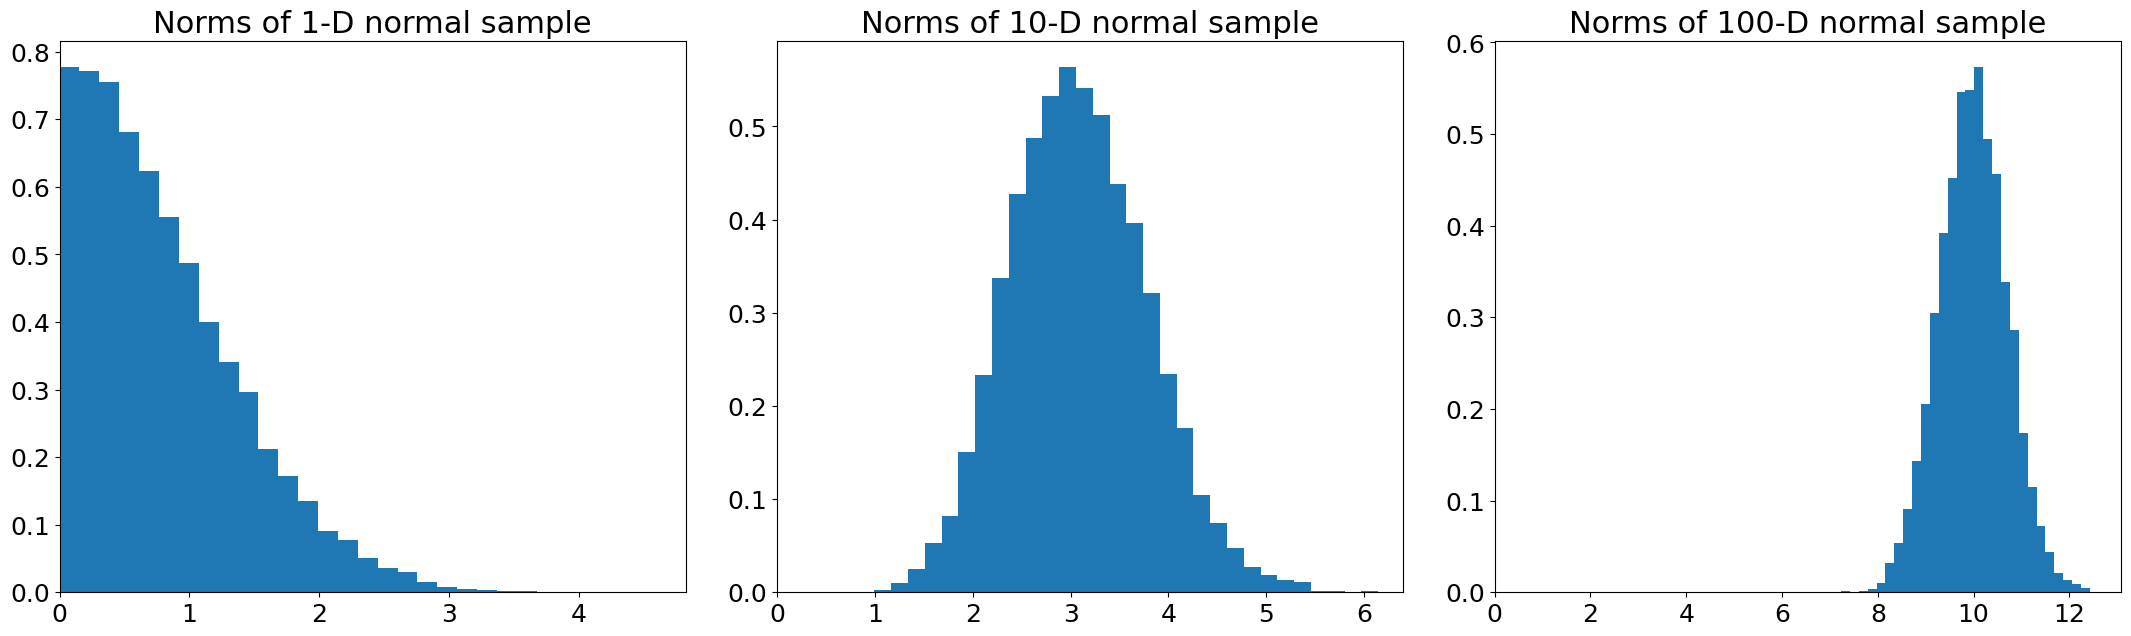

In [9]:
def generate_sample(d, N=10_000):
    return np.random.standard_normal(size=(N, d))


x1 = generate_sample(1)
x10 = generate_sample(10)
x100 = generate_sample(100)

f, ax = plt.subplots(figsize=(22, 7), ncols=3)

ax[0].tick_params(axis="both", which="major", labelsize=18)
ax[1].tick_params(axis="both", which="major", labelsize=18)
ax[2].tick_params(axis="both", which="major", labelsize=18)

ax[0].hist(np.linalg.norm(x1, axis=1), density=True, bins=30)
ax[1].hist(np.linalg.norm(x10, axis=1), density=True, bins=30)
ax[2].hist(np.linalg.norm(x100, axis=1), density=True, bins=30)

ax[0].set_xlim(left=0)
ax[1].set_xlim(left=0)
ax[2].set_xlim(left=0)

ax[0].set_title("Norms of 1-D normal sample", fontsize=22)
ax[1].set_title("Norms of 10-D normal sample", fontsize=22)
ax[2].set_title("Norms of 100-D normal sample", fontsize=22)

f.tight_layout(pad=3)

f.savefig("normal_sample_radius.png")

## The leapfrog integrator

The leapfrog integrator is a symplectic integrator that doesn't accumulate errors in the same way that alternative algorithms do. We compare it to three alternatives with the simple Hamiltonian

$$
    H(q, p) = \frac{q^2 + p^2}{2}
$$

In [10]:
step_size = 0.3

# Euler's method
q, p = np.array([0, 1])
qs = [q]
ps = [p]

for i in range(100):
    q_new = q + step_size * p
    p_new = p - step_size * q
    qs.append(q_new)
    ps.append(p_new)
    q, p = q_new, p_new

# modified Euler's method
q, p = np.array([0, 1])
qs_mod = [q]
ps_mod = [p]

for i in range(100):
    q_new = q + step_size * p
    p_new = p - step_size * q_new
    qs_mod.append(q_new)
    ps_mod.append(p_new)
    q, p = q_new, p_new

# the leapfrog integrator
q, p = np.array([0, 1])
qs_lf = [q]
ps_lf = [p]

for i in range(100):
    p_new = p - 0.5 * step_size * q
    q_new = q + step_size * p_new
    p_new = p_new - 0.5 * step_size * q_new
    qs_lf.append(q_new)
    ps_lf.append(p_new)
    q, p = q_new, p_new

The following cell makes a simple animation comparing each approximation scheme with the analytic solution (a circle).

In [11]:
f, ax = plt.subplots(ncols=3, figsize=(22, 7))

t = np.linspace(0, 2 * np.pi, 1001)
x = np.cos(t)
y = np.sin(t)

for a in ax:
    a.plot(x, y, c="#333333", alpha=0.3)


for a in ax:
    a.set_xlim(-2, 2)
    a.set_ylim(-2, 2)

(euler,) = ax[0].plot([], [])
(mod_euler,) = ax[1].plot([], [])
(lf,) = ax[2].plot([], [])


ax[0].set_title("Euler's method", fontsize=18)
ax[1].set_title("Modified Euler's method", fontsize=18)
ax[2].set_title("Leapfrog Integrator", fontsize=18)

f.tight_layout(pad=3)

writer = FFMpegWriter(fps=5)

with writer.saving(f, "integrator.mp4", 50):
    # initial empty frames
    for _ in range(5):
        writer.grab_frame()

    for i in range(1, 25):
        euler.set_data(qs[:i], ps[:i])
        mod_euler.set_data(qs_mod[:i], ps_mod[:i])
        lf.set_data(qs_lf[:i], ps_lf[:i])

        writer.grab_frame()


plt.close()

In [12]:
Video("integrator.mp4")

## Hamiltonian Monte Carlo

The algorithm is as follows:

1. Choose a starting point $q^{(0)}$ in parameter space, and fix a step size $\varepsilon$ and a path length $L$.
2. Given parameters $q^{(n)}$ we sample $p^{(n)} \sim \mathcal N(0, I)$. More generally we could sample from $\mathcal{N}(0, M)$ where $M \approx \mathrm{cov}(q)$. We will however keep things simple and just use the identity matrix.
3. We set $(q_0, p_0) = (q^{(n)}, p^{(n)})$. Evolve $(q_0, p_0)$ for $L$ steps using the leapfrog integrator to obtain $(q_L, p_L)$, an approximation of $(q(\varepsilon L), p(\varepsilon L))$. 
4. Sample $r \sim \mathrm{Unif}(0, 1)$ and let $q^{(n+1)} = q_L$ if $\pi(q_L, p_L) / \pi(q^{(n)}, p^{(n)}) < r$, or $q^{(n+1)} = q^{(n)}$ otherwise.
5. Repeat

First the leapfrog integrator.

In [13]:
def leapfrog(q0, p0, target, L, step_size):
    q = q0.copy()
    p = p0.copy()

    for i in range(L):
        p += target.grad_log_density(q) * step_size / 2
        q += p * step_size
        p += target.grad_log_density(q) * step_size / 2

    return q, p

Here is a basic implementation of Hamiltonian Monte Carlo

In [14]:
def hmc(target, initial, iterations=10_000, L=50, step_size=0.1):
    samples = [initial()]

    for i in range(iterations):
        q0 = samples[-1]
        p0 = np.random.standard_normal(size=q0.size)

        q_star, p_star = leapfrog(q0, p0, target, L, step_size)

        h0 = -target.log_density(q0) + (p0 * p0).sum() / 2
        h = -target.log_density(q_star) + (p_star * p_star).sum() / 2
        log_accept_ratio = h0 - h

        if np.random.random() < np.exp(log_accept_ratio):
            samples.append(q_star)
        else:
            samples.append(q0)

    return samples

We make a slight modification to the donut target density as we require the log density and the gradients of the log density rather than the density itself.

In [15]:
class DonutPDF:
    def __init__(self, radius=3, sigma2=0.05):
        self.radius = radius
        self.sigma2 = sigma2

    def log_density(self, x):
        r = np.linalg.norm(x)
        return -((r - self.radius) ** 2) / self.sigma2

    def grad_log_density(self, x):
        r = np.linalg.norm(x)
        if r == 0:
            return np.zeros_like(x)
        return 2 * x * (self.radius / r - 1) / self.sigma2

Draw samples with HMC

In [16]:
hmc_samples = hmc(DonutPDF(), lambda: np.array([3, 0.0]));

To make an animation of what's going on here, we need to make a modified version of the leapfrog integrator that also saves the trajectory that lead to each proposal.

In [17]:
def leapfrog_traj(q0, p0, target, L, step_size):
    q = q0.copy()
    p = p0.copy()
    traj = [q.copy()]

    for i in range(L):
        p += target.grad_log_density(q) * step_size / 2
        q += p * step_size
        p += target.grad_log_density(q) * step_size / 2
        traj.append(q.copy())

    return q, p, traj

Manually run HMC while making an animation.

In [18]:
f, ax = plt.subplots(figsize=(7, 7))

points = np.linspace(-4, 4, 101)
x = np.tile(points, len(points))
y = np.repeat(points, len(points))

donut = DonutPDF()
z = np.exp(np.apply_along_axis(donut.log_density, 1, np.column_stack([x, y])))

ax.contour(
    points,
    points,
    z.reshape(len(points), len(points)),
    cmap="plasma",
    alpha=0.5,
)

(samps,) = ax.plot([], [], "o", alpha=0.7)
(traj,) = ax.plot([], [], "k")

writer = FFMpegWriter(fps=15)

with writer.saving(f, "donut_hmc.mp4", 50):
    # initial empty frame
    writer.grab_frame()

    samples = [np.array([3.0, 0.0])]
    samps.set_data(*(np.array(samples).T))

    writer.grab_frame()

    for i in range(100):
        q0 = samples[-1]
        p0 = np.random.normal(scale=2.0, size=q0.size)

        q_star, p_star, trajectory = leapfrog_traj(q0, p0, donut, 20, 0.1)

        h0 = -donut.log_density(q0) + (p0 * p0).sum() / 2
        h = -donut.log_density(q_star) + (p_star * p_star).sum() / 2
        log_accept_ratio = h0 - h

        # animate the trajectory
        for j in range(len(trajectory)):
            traj.set_data(*np.array(trajectory[: j + 1]).T)
            writer.grab_frame()

        # flash green or red to signal acceptance / rejection
        if np.random.random() < np.exp(log_accept_ratio):
            samples.append(q_star)
            traj.set_color("tab:green")
        else:
            samples.append(q0)
            traj.set_color("tab:red")

        for _ in range(2):
            writer.grab_frame()

        traj.set_color("black")
        traj.set_data([], [])
        samps.set_data(*(np.array(samples).T))
        writer.grab_frame()

plt.close()

In [22]:
Video("donut_hmc.mp4")

## Comparing algorithms

To finish, let's compare HMC to the two variants of MCMC. We use the samples from earlier in the notebook.

In [20]:
f, ax = plt.subplots(ncols=3, figsize=(18, 7))

hmc_samples = np.array(hmc_samples)

points = np.linspace(-4, 4, 101)
x = np.tile(points, len(points))
y = np.repeat(points, len(points))

donut = DonutPDF()
z = np.exp(np.apply_along_axis(donut.log_density, 1, np.column_stack([x, y])))

for a in ax:
    a.contour(
        points,
        points,
        z.reshape(len(points), len(points)),
        cmap="plasma",
        alpha=0.1,
    )

(mcmc05_scat,) = ax[0].plot([], [], ".", alpha=0.2, ms=10)
(mcmc1_scat,) = ax[1].plot([], [], ".", alpha=0.2, ms=10)
(hmc_scat,) = ax[2].plot([], [], ".", alpha=0.2, ms=10)

title05 = ax[0].set_title(
    "RW-Metropolis - scale = 0.05\n# samples: 0\nAccept rate: N/A", fontsize=18
)
title1 = ax[1].set_title(
    "RW-Metropolis - scale = 1.0\n# samples: 0\nAccept rate: N/A", fontsize=18
)
title_hmc = ax[2].set_title("HMC\n# samples: 0\nAccept rate: N/A", fontsize=18)

for a in ax:
    a.set_xlim(-4, 4)
    a.set_ylim(-4, 4)

f.tight_layout(pad=4)

writer = FFMpegWriter(fps=25)

with writer.saving(f, "donut_compare.mp4", 50):
    # initial empty frame
    writer.grab_frame()

    for i in range(1, 1000):
        mcmc05_scat.set_data(*samples05[: i + 1].T)
        mcmc1_scat.set_data(*samples1[: i + 1].T)
        hmc_scat.set_data(*hmc_samples[: i + 1].T)

        accept05 = 1 - (samples05[1 : i + 1] == samples05[:i]).all(axis=1).mean()
        accept1 = 1 - (samples1[1 : i + 1] == samples1[:i]).all(axis=1).mean()
        accept_hmc = 1 - (hmc_samples[1 : i + 1] == hmc_samples[:i]).all(axis=1).mean()

        title05.set_text(
            f"RW-Metropolis - scale = 0.05\n# samples: {i+1}\nAccept rate: {accept05 * 100:.2f}%"
        )
        title1.set_text(
            f"RW-Metropolis - scale = 1.0\n# samples: {i+1}\nAccept rate: {accept1 * 100:.2f}%"
        )
        title_hmc.set_text(
            f"HMC\n# samples: {i+1}\nAccept rate: {accept_hmc * 100:.2f}%"
        )

        writer.grab_frame()

plt.close()

In [21]:
Video("donut_compare.mp4")